## Necessary Imports

In [6]:
import os
import sys
import cv2
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from skimage.feature import hog
import pickle as pkl

## Dataset path

In [3]:
train_path = r"D:\Seed Quality Prediction\data-20260503T170400Z-3-001\data\train"
val_path = r"D:\Seed Quality Prediction\data-20260503T170400Z-3-001\data\val"

img_size = 224

## Load Data Function

In [4]:
def load_image(path):
    features = []
    labels = []

    interpolation = cv2.INTER_AREA
    for label in os.listdir(path):
        folder = os.path.join(path,label)
        if not os.path.isdir(folder): continue

        for image in os.listdir(folder):
            image_path = os.path.join(folder, image)
            
            img = cv2.imread(image_path)

            if img is None: continue

            # resize
            img = cv2.resize(img, (img_size, img_size), interpolation=interpolation)

            # Gaussian Blur
            img = cv2.GaussianBlur(img, (3,3),0)

            # convert to gray
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            # Extract Histogram of Oriented Gradients (HOG) for a given image.
            hog_feature = hog(
               gray,
                orientations = 12,
                pixels_per_cell = (8,8),
                cells_per_block = (2,2),
                block_norm = 'L2-Hys',
                visualize = False,
                feature_vector = True
            )


            # Color Histogram Feature
            hist_b = cv2.calcHist([img],[0],None,[32],[0,256])
            hist_g = cv2.calcHist([img],[1],None,[32],[0,256])
            hist_r = cv2.calcHist([img],[2],None,[32],[0,256])

            color_feature = np.concatenate([
                hist_b.flatten(),
                hist_g.flatten(),
                hist_r.flatten()
            ])

            final_feature = np.concatenate([
                hog_feature,
                color_feature
            ])
            features.append(final_feature)
            labels.append(label)
    return (
        np.asarray(features, dtype = np.float32),
        np.asarray(labels)
    )


## Load Data

In [5]:
X_train, y_train= load_image(train_path)
X_test, y_test= load_image(val_path)

print(X_train.shape)
print(X_test.shape)

(14340, 35088)
(3479, 35088)


## Feature Scaling

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## PCA 


In [8]:
pca = PCA(
    n_components = 500,
    random_state=42
)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


In [9]:
X_train_pca.shape

(14340, 500)

## Models


In [10]:
model = SVC(kernel = 'rbf', C=10, gamma = 'scale')
model.fit(X_train_pca, y_train)

SVC(C=10)

In [11]:
y_pred = model.predict(X_test_pca)

print(accuracy_score(y_test, y_pred))

0.6320781833860305


## Confusion Matrix


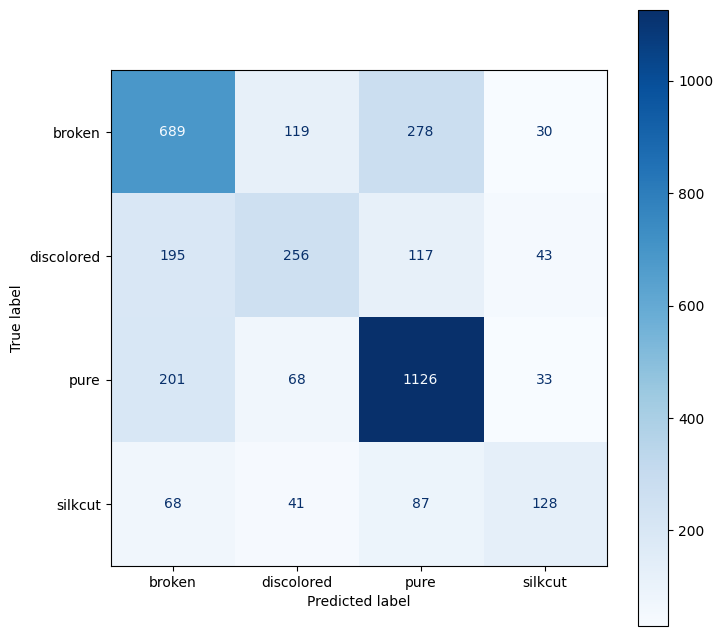

In [12]:
cm = confusion_matrix(y_test,y_pred)

fig,ax = plt.subplots(figsize = (8,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels = model.classes_
)

disp.plot(
    ax=ax,
    cmap = 'Blues'
)

plt.show()